In [3]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

In [4]:
# Setup plot styles for saving figures.
def figure_style():
    global plotStyles,stepStyles
    matplotlib.rcParams.update({"axes.formatter.limits": (-4,4), "svg.fonttype" : "none", 'pdf.fonttype':42,'font.family':'sans-serif','font.sans-serif':'Helvetica','font.size': 9, "axes.titlesize": 10, "xtick.labelsize": 8, "ytick.labelsize": 8,'text.usetex':True,'text.latex.preamble':[r'\usepackage{sansmath}',r'\sansmath']})
    plotStyles={"markersize":4,"markeredgewidth":1.0,"linewidth":1.0}
    stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}

In [5]:
# Setup plot styles for on-screen plotting.
def screen_style(fontSize=20):
    global plotStyles,stepStyles
    matplotlib.rcParams.update({"axes.formatter.limits": (-4,4), "svg.fonttype" : "none", 'pdf.fonttype':42,'font.family':'sans-serif','font.sans-serif':'Helvetica','font.size': fontSize, "axes.titlesize": fontSize, "xtick.labelsize": fontSize, "ytick.labelsize": fontSize,'text.usetex':True,'text.latex.preamble':[r'\usepackage{sansmath}',r'\sansmath']})
    plotStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0}
    stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}

In [6]:
%%javascript
IPython.OutputArea.auto_scroll_threshold = 9999;

<IPython.core.display.Javascript object>

# Regression tests for 1D diffusion.

### Execute a simulation of a 1D diffusion domain with various boundaries.

In [62]:
# Set the directory.
dirname="data/1"

# Create the input file.
import lm.input.SimulationInput_pb2 as inp
import lm.io.BoundaryConditions_pb2 as bc
from robertslab import ndarray
from robertslab.sfile import SFile

# Build the microenv model.
for axis in ("x","y","z"):
    for boundary in (bc.BoundaryConditions().REFLECTING,bc.BoundaryConditions().ABSORBING,bc.BoundaryConditions().LINEAR_GRADIENT):
        input=inp.SimulationInput()
        input.microenv_model.grid_spacing = 4.0e-6
        input.microenv_model.species_ids.append(0)
        input.microenv_model.diffusion_coefficients.append(1000e-12)
        input.microenv_model.boundaries.axis_specific_boundaries = True
        input.microenv_model.initial_time = 0.0;
        input.microenv_model.synchronization_timestep = 0.01;
        input.microenv_model.boundaries.x_plus = bc.BoundaryConditions().REFLECTING
        input.microenv_model.boundaries.x_minus = bc.BoundaryConditions().REFLECTING
        input.microenv_model.boundaries.y_plus = bc.BoundaryConditions().REFLECTING
        input.microenv_model.boundaries.y_minus = bc.BoundaryConditions().REFLECTING
        input.microenv_model.boundaries.z_plus = bc.BoundaryConditions().REFLECTING
        input.microenv_model.boundaries.z_minus = bc.BoundaryConditions().REFLECTING
        if axis == "x":
            gridShape=(100,1,1)
            input.microenv_model.boundaries.x_plus = boundary
            input.microenv_model.boundaries.x_minus = boundary
        elif axis == "y":
            gridShape=(1,100,1)
            input.microenv_model.boundaries.y_plus = boundary
            input.microenv_model.boundaries.y_minus = boundary
        elif axis == "z":
            gridShape=(1,1,100)
            input.microenv_model.boundaries.z_plus = boundary
            input.microenv_model.boundaries.z_minus = boundary

        # Set the initial grid.
        input.microenv_model.grid_shape.extend(gridShape)
        grid = np.zeros(gridShape)
        grid[grid.shape[0]//2,grid.shape[1]//2,grid.shape[2]//2] = 1.0e-6
        ndarray.serializeInto(input.microenv_model.initial_concentrations.add(), grid)

        # Write the input to the file.
        filename="%s/microenv-input-%s-%d.sfile"%(dirname,axis,boundary)
        file=SFile.fromFilename(filename, "w")
        file.writeRecord("input", "protobuf:lm.input.SimulationInput", stringData=input.SerializeToString())
        file.close()
        
print "Finished."

Wrote 105 byte of string data
Wrote 105 byte of string data
Wrote 105 byte of string data
Wrote 105 byte of string data
Wrote 105 byte of string data
Wrote 105 byte of string data
Wrote 105 byte of string data
Wrote 105 byte of string data
Wrote 105 byte of string data
Finished.


In [76]:
%%bash
dirname=data/1
mkdir -p ${dirname}
for axis in x y z; do
    for boundary in 0 1 5; do
        filename=${dirname}/simulation-input-$axis-$boundary.lm
        rm -f ${filename} && lm_sbml_import ${filename} microenv_diffusion.sbml > /dev/null
        lm_setp ${filename} writeInterval=1e-1 maxTime=1e2 > /dev/null
    done;
done;
echo "Execute the following commands in `pwd`:"
for axis in x y z; do
    for boundary in 0 1 5; do
        filename=${dirname}/simulation-input-$axis-$boundary.lm
        ifilename=${dirname}/microenv-input-$axis-$boundary.sfile
        ofilename=${dirname}/output-$axis-$boundary.sfile
        rm -f ${ofilename}
        echo "lmes -me -f ${filename},${ifilename} -gr 0 -c 3 -r 0 -ff sfile -fo ${ofilename} -sl lm::cme::GillespieDSolver"
    done;
done;
echo ""

Execute the following commands in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/microenv_diffusion:
lmes -me -f data/1/simulation-input-x-0.lm,data/1/microenv-input-x-0.sfile -gr 0 -c 3 -r 0 -ff sfile -fo data/1/output-x-0.sfile -sl lm::cme::GillespieDSolver
lmes -me -f data/1/simulation-input-x-1.lm,data/1/microenv-input-x-1.sfile -gr 0 -c 3 -r 0 -ff sfile -fo data/1/output-x-1.sfile -sl lm::cme::GillespieDSolver
lmes -me -f data/1/simulation-input-x-5.lm,data/1/microenv-input-x-5.sfile -gr 0 -c 3 -r 0 -ff sfile -fo data/1/output-x-5.sfile -sl lm::cme::GillespieDSolver
lmes -me -f data/1/simulation-input-y-0.lm,data/1/microenv-input-y-0.sfile -gr 0 -c 3 -r 0 -ff sfile -fo data/1/output-y-0.sfile -sl lm::cme::GillespieDSolver
lmes -me -f data/1/simulation-input-y-1.lm,data/1/microenv-input-y-1.sfile -gr 0 -c 3 -r 0 -ff sfile -fo data/1/output-y-1.sfile -sl lm::cme::GillespieDSolver
lmes -me -f data/1/simulation-input-y-5.lm,data/1/microenv-input-y-5.sfile -gr 0 -c 3 -r 0 -f

### Plot the concentration vs time.

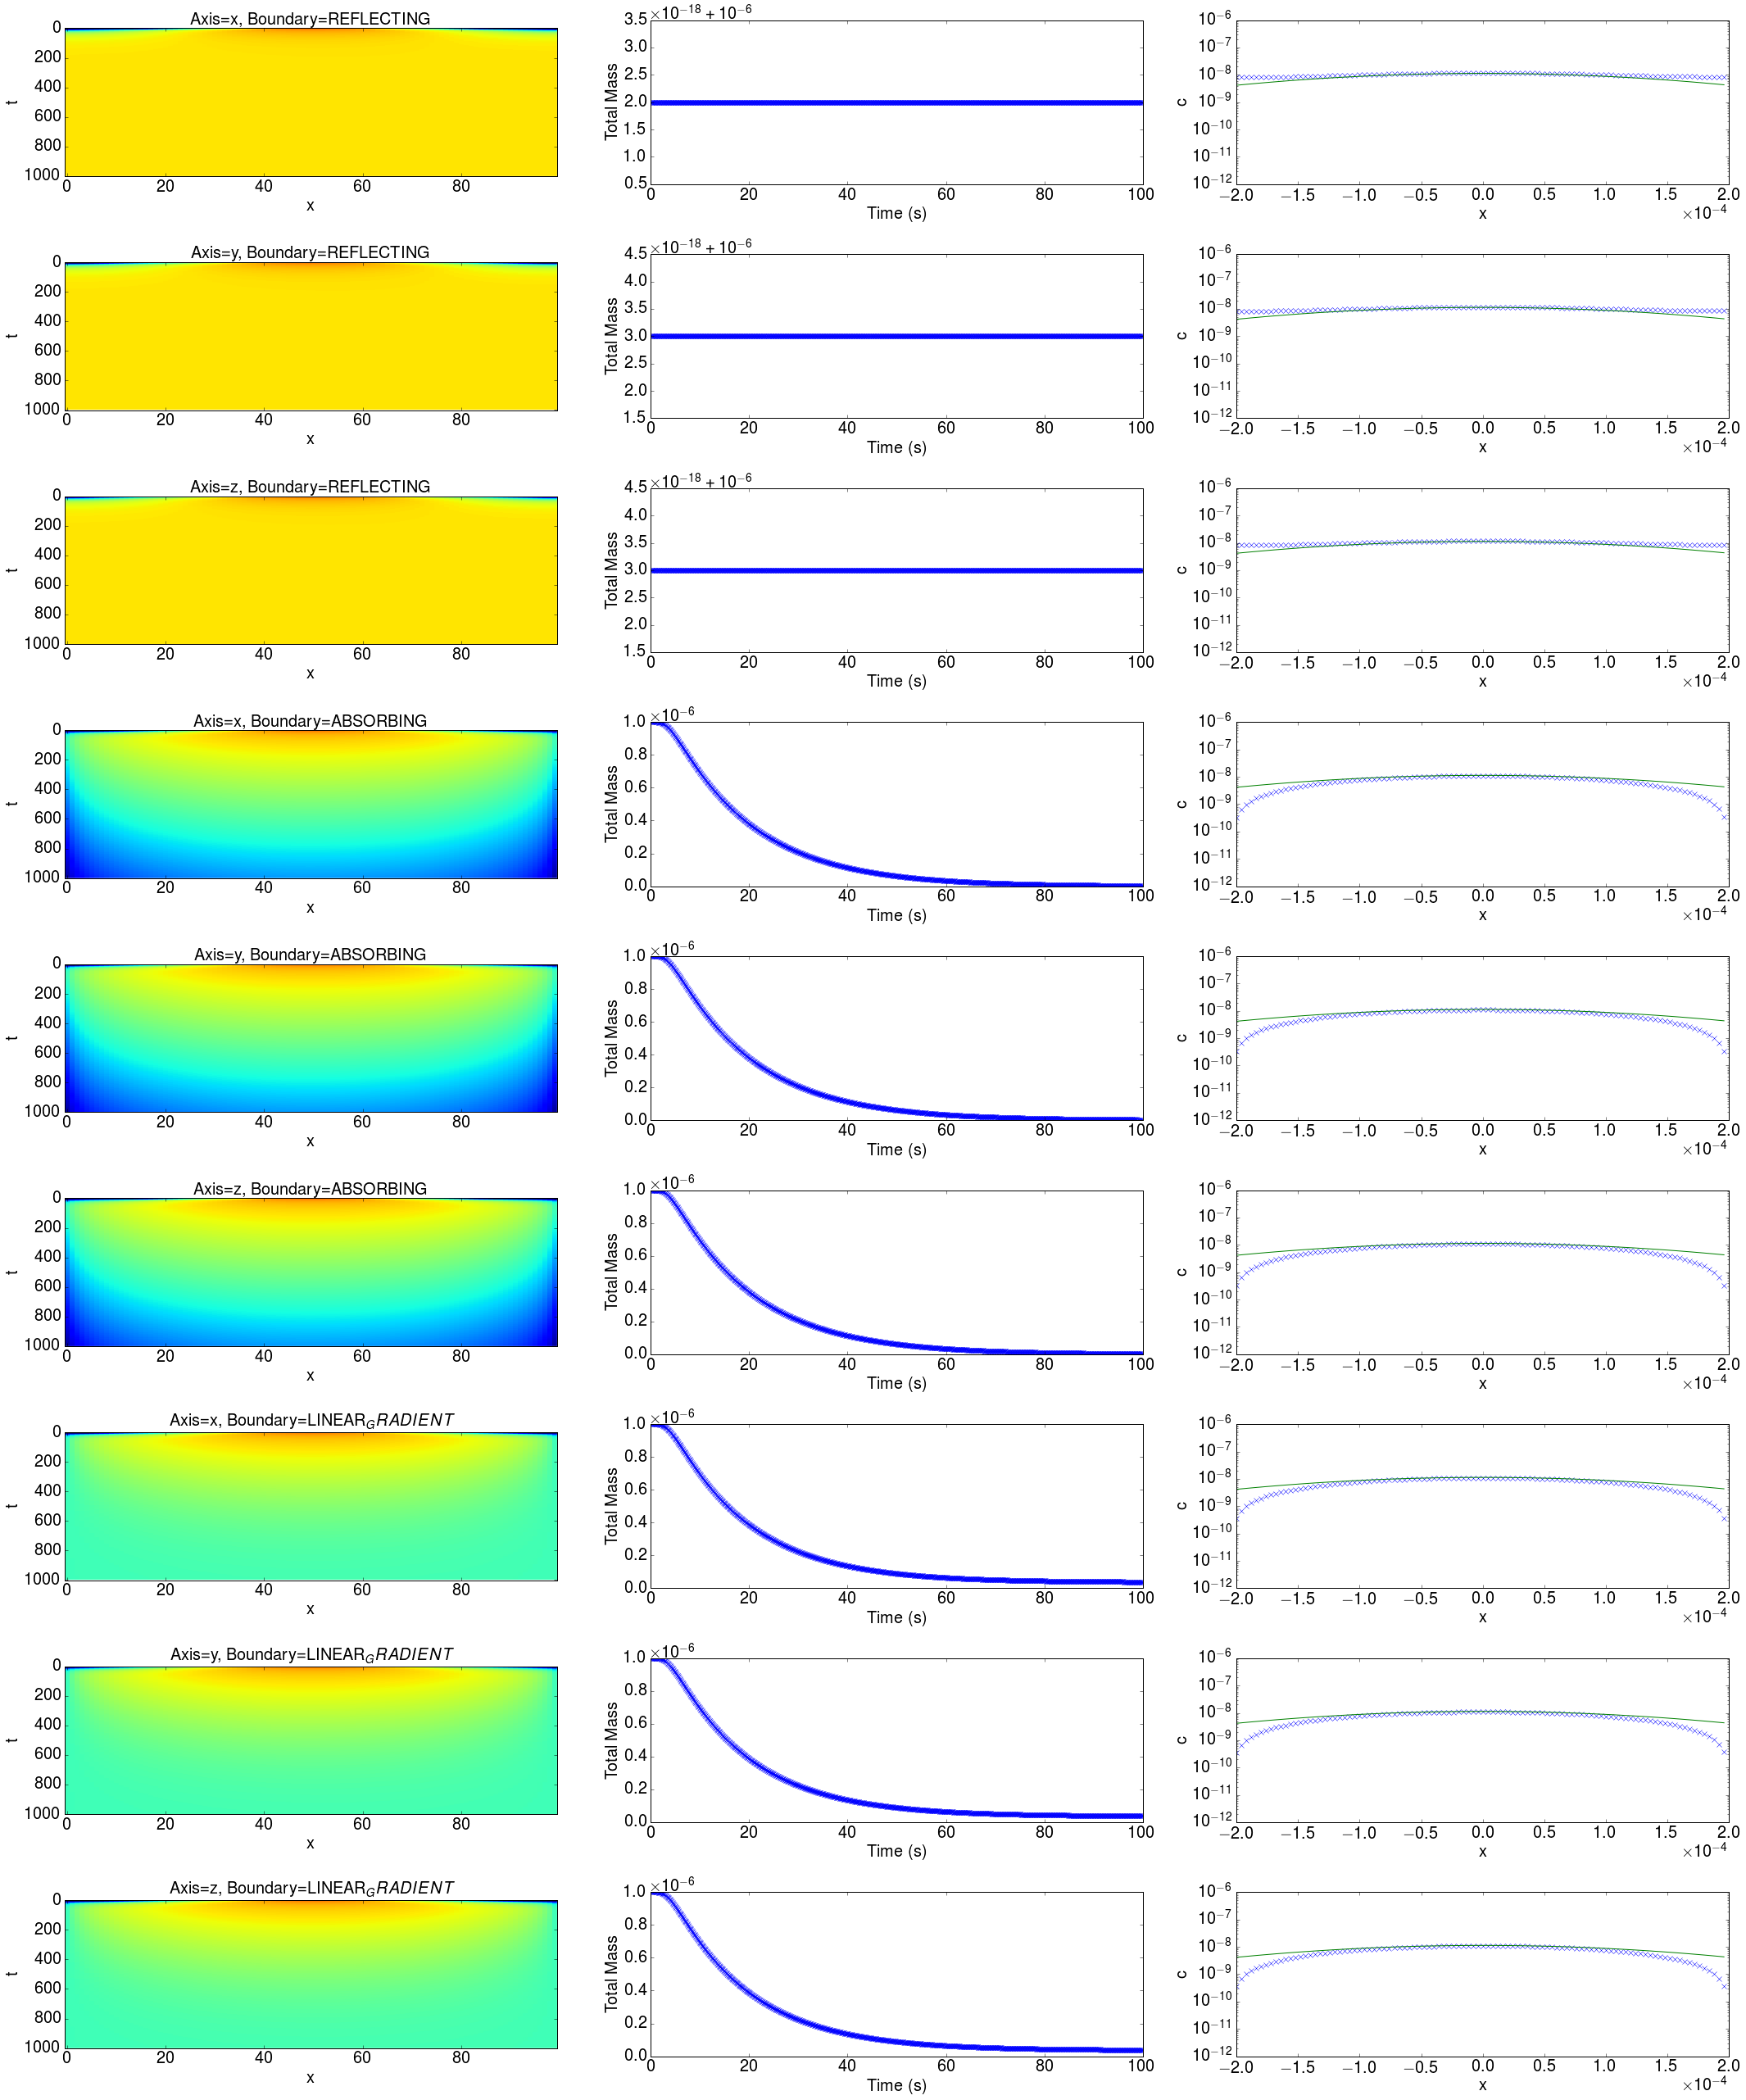

In [131]:
dirname="data/1"

from robertslab import ndarray
from robertslab.sfile import SFile
import lm.io.ConcentrationsTimeSeries_pb2 as cts

rows=9; cols=3; plotIndex=1
screen_style()
matplotlib.rcParams.update({"figure.figsize": (30,rows*4)})
for boundary in (bc.BoundaryConditions().REFLECTING,bc.BoundaryConditions().ABSORBING,bc.BoundaryConditions().LINEAR_GRADIENT):
    for i,axis in enumerate(("x","y","z")):
        
        # Set the filename.
        filename="%s/output-%s-%d.sfile"%(dirname,axis,boundary)

        # Get the grid size and count the entries.
        numberRecords=0
        gridShape=None
        file=SFile.fromFilename(filename, "r")
        while True:
            record=file.readNextRecord()
            if record is None: break
            if record.name == "/Simulations/0/ConcentrationsTimeSeries":
                obj=cts.ConcentrationsTimeSeries()
                obj.ParseFromString(file.readData(record.dataSize))
                numberRecords += obj.times.shape[0]
                if gridShape is None:
                    gridShape = tuple(obj.concentrations[0].shape)
            else:
                file.skipData(record.dataSize)
        file.close();

        # Load the records for this replicate.
        index=0
        times=np.zeros((numberRecords,), dtype=float)
        grids=np.zeros((numberRecords,gridShape[i]), dtype=float)
        file=SFile.fromFilename(filename, "r")
        while True:
            record=file.readNextRecord()
            if record is None: break
            if record.name == "/Simulations/0/ConcentrationsTimeSeries":
                obj=cts.ConcentrationsTimeSeries()
                obj.ParseFromString(file.readData(record.dataSize))
                recordTimes = ndarray.deserializeMessage(obj.times)
                for j in range(0,recordTimes.shape[0]):
                    times[index] = recordTimes[j]
                    grids[index,:] = ndarray.deserializeMessage(obj.concentrations[j]).flatten()
                    index += 1
            else:
                file.skipData(record.dataSize)
        file.close();
        #print "Finished loading, grid shape was: ",gridShape,", number of time points was: ",len(times)

        # Plot the figure.
        subplot(rows,cols,plotIndex)
        imshow(log10(grids[:,:]), interpolation='none', aspect=0.03, origin='upper', vmin=-12, vmax=-6)
        #cb=colorbar(label="c"); cb.ax.set_aspect(5)
        xlabel("x"); ylabel("t"); title(r"Axis=%s, Boundary=%s"%(axis,bc.BoundaryConditions().BoundaryConditionsType.Name(boundary)))
        subplot(rows,cols,plotIndex+1)
        mass=np.sum(grids, (1,))
        plot(times, mass, 'x')
        xlabel("Time (s)"); ylabel("Total Mass")
        subplot(rows,cols,plotIndex+2)
        ti=100
        t=times[ti]
        D=1000e-12
        l=4e-6
        x=(np.arange(0,grids.shape[1])-50)*l
        N=1e-6*l
        ctheory=(N/sqrt(4*pi*D*t))*exp(-((x**2)/(4*D*t)))
        plot(x,grids[ti,:], 'x')
        plot(x,ctheory, '-')
        xlabel("x"); ylabel("c"); yscale("log"); ylim([1e-12,1e-6])
        plotIndex += 3
        
plt.tight_layout()
pass

### Execute a simulation of a large 1D diffusion domain with linear gradient boundaries.

In [94]:
dirname="data/2"

# Create the microenv model input file.
import lm.input.SimulationInput_pb2 as inp
import lm.io.BoundaryConditions_pb2 as bc
from robertslab import ndarray
from robertslab.sfile import SFile

input=inp.SimulationInput()

# Build the microenv model.
gridShape=(1,1,10000)
input.microenv_model.initial_time = 0.0;
input.microenv_model.synchronization_timestep = 0.01;
input.microenv_model.grid_shape.extend(gridShape)
input.microenv_model.grid_spacing = 4.0e-6
input.microenv_model.species_ids.append(0)
input.microenv_model.diffusion_coefficients.append(1000e-12)
input.microenv_model.boundaries.axis_specific_boundaries = True
input.microenv_model.boundaries.x_plus = bc.BoundaryConditions().REFLECTING
input.microenv_model.boundaries.x_minus = bc.BoundaryConditions().REFLECTING
input.microenv_model.boundaries.y_plus = bc.BoundaryConditions().REFLECTING
input.microenv_model.boundaries.y_minus = bc.BoundaryConditions().REFLECTING
input.microenv_model.boundaries.z_plus = bc.BoundaryConditions().LINEAR_GRADIENT
input.microenv_model.boundaries.z_minus = bc.BoundaryConditions().LINEAR_GRADIENT
grid = np.zeros(gridShape)
grid[grid.shape[0]//2,grid.shape[1]//2,grid.shape[2]//2] = 1.0e-6
ndarray.serializeInto(input.microenv_model.initial_concentrations.add(), grid)

# Write the input to the file.
filename="%s/input.sfile"%dirname
file=SFile.fromFilename(filename, "w")
file.writeRecord("input", "protobuf:lm.input.SimulationInput", stringData=input.SerializeToString())
file.close()
print "Finished."

Wrote 473 byte of string data
Finished.


In [93]:
%%bash
dirname=data/2
filename=${dirname}/microenv_diffusion.lm
ifilename=${dirname}/input.sfile
ofilename=${dirname}/output.sfile
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} microenv_diffusion.sbml
lm_setp ${filename} writeInterval=1e-1 maxTime=1e2
rm -f ${sfilename}
echo "Execute the following command in `pwd`:"
echo "lmes -me -f ${filename},${ifilename} -gr 0 -c 3 -r 0 -ff sfile -fo ${ofilename}" -sl lm::cme::GillespieDSolver


lm_sbml_import v2016.05.10 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


2016-05-27 12:06:21) Processing 1 compartments.
2016-05-27 12:06:21) Added compartment (0) V: 1.000000e+00
2016-05-27 12:06:21) Processing 1 species.
2016-05-27 12:06:21) Added species (0) n with initial count: 1000
2016-05-27 12:06:21) Processing 1 reactions.
2016-05-27 12:06:21) Matched kinetic formula in reaction (0)  to FirstOrderPropensity: [1 * n] == [k1 * x1]
2016-05-27 12:06:21) There output file was successfully genereated.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/2/microenv_diffusion.lm:
maxTime=1e2
writeInterval=1e-1
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/microenv_diffusion:
lmes -me -f data/2/microenv_diffus

### Load the concentration time series.

In [95]:
# Set the filename.
dirname="data/2"
filename="%s/output.sfile"%dirname

from robertslab import ndarray
from robertslab.sfile import SFile
import lm.io.ConcentrationsTimeSeries_pb2 as cts

# Get the grid size and count the entries.
numberRecords=0
gridShape=None
file=SFile.fromFilename(filename, "r")
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.name == "/Simulations/0/ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        numberRecords += obj.times.shape[0]
        if gridShape is None:
            gridShape = tuple(obj.concentrations[0].shape)
    else:
        file.skipData(record.dataSize)
file.close();

# Load the records for this replicate.
index=0
times=np.zeros((numberRecords,), dtype=float)
grids=np.zeros((numberRecords,gridShape[2]), dtype=float)
file=SFile.fromFilename(filename, "r")
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.name == "/Simulations/0/ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        recordTimes = ndarray.deserializeMessage(obj.times)
        for j in range(0,recordTimes.shape[0]):
            times[index] = recordTimes[j]
            grids[index,:] = ndarray.deserializeMessage(obj.concentrations[j])
            index += 1
    else:
        file.skipData(record.dataSize)
file.close();
print "Finished loading, grid shape was: ",gridShape,", number of time points was: ",len(times)
pass

Finished loading, grid shape was:  (1, 1, 10000) , number of time points was:  1001


### Plot the concentration vs time.

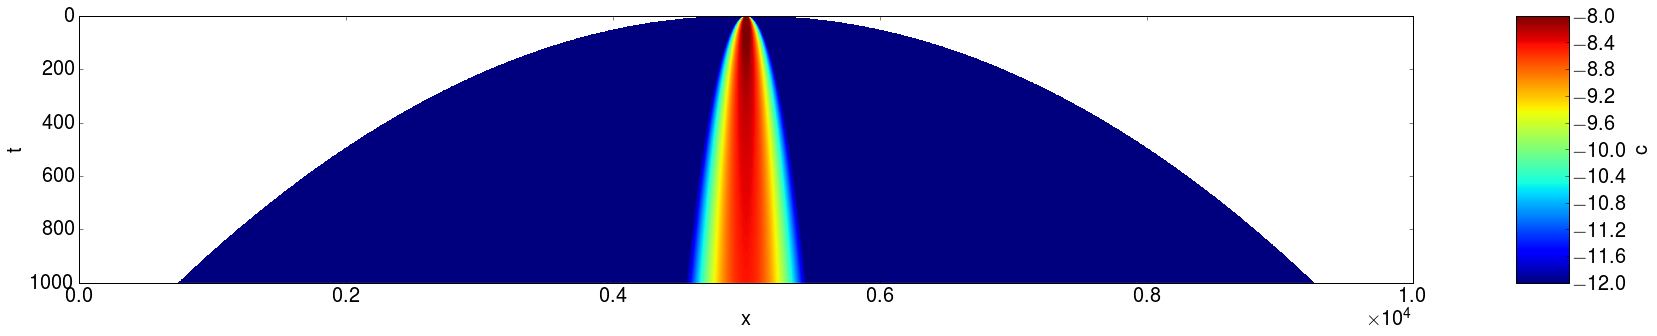

In [96]:
# Plot the full domain.
screen_style()
matplotlib.rcParams.update({"figure.figsize": (30,5)})
imshow(log10(grids[:,:]), interpolation='none', aspect=2, origin='upper', vmin=-12, vmax=-8)
cb=colorbar(label="c"); cb.ax.set_aspect(5)
xlabel("x"); ylabel("t");
plt.tight_layout()
pass

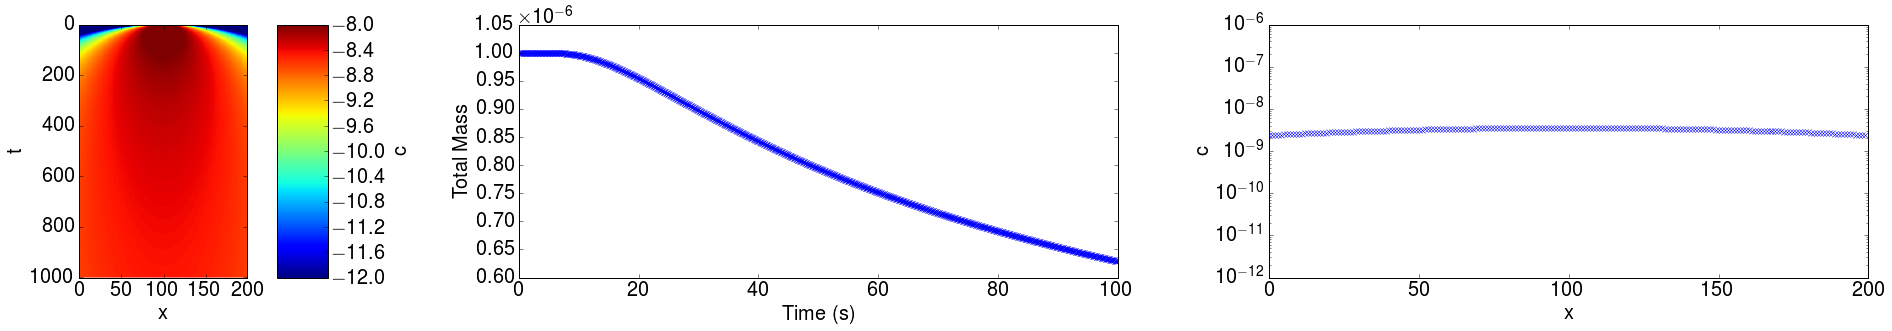

In [102]:
# Plot the domains from -100 to 100.
grids2=grids[:,5000-100:5000+100]
screen_style()
subplot(1,3,1)
matplotlib.rcParams.update({"figure.figsize": (30,5)})
imshow(log10(grids2), interpolation='none', aspect=0.3, origin='upper', vmin=-12, vmax=-8)
cb=colorbar(label="c"); cb.ax.set_aspect(5)
xlabel("x"); ylabel("t");
subplot(1,3,2)
mass=np.sum(grids2, (1,))
plot(times, mass, 'x')
xlabel("Time (s)"); ylabel("Total Mass")
subplot(1,3,3)
plot(np.arange(0,grids2.shape[1]),grids2[-1,:], 'x')
xlabel("x"); ylabel("c"); yscale("log"); ylim([1e-12,1e-6])
plt.tight_layout()
pass

### Compare the numeric and analytic concentration at different times.
The concentration as a fucntion of $x$ and $t$ is given by $c(x,t) = \frac{N}{\sqrt{4{\pi}Dt}} exp(-\frac{x^2}{4Dt})$, where $N=\int_{-\infty}^{\infty}c(x,t)dx$.

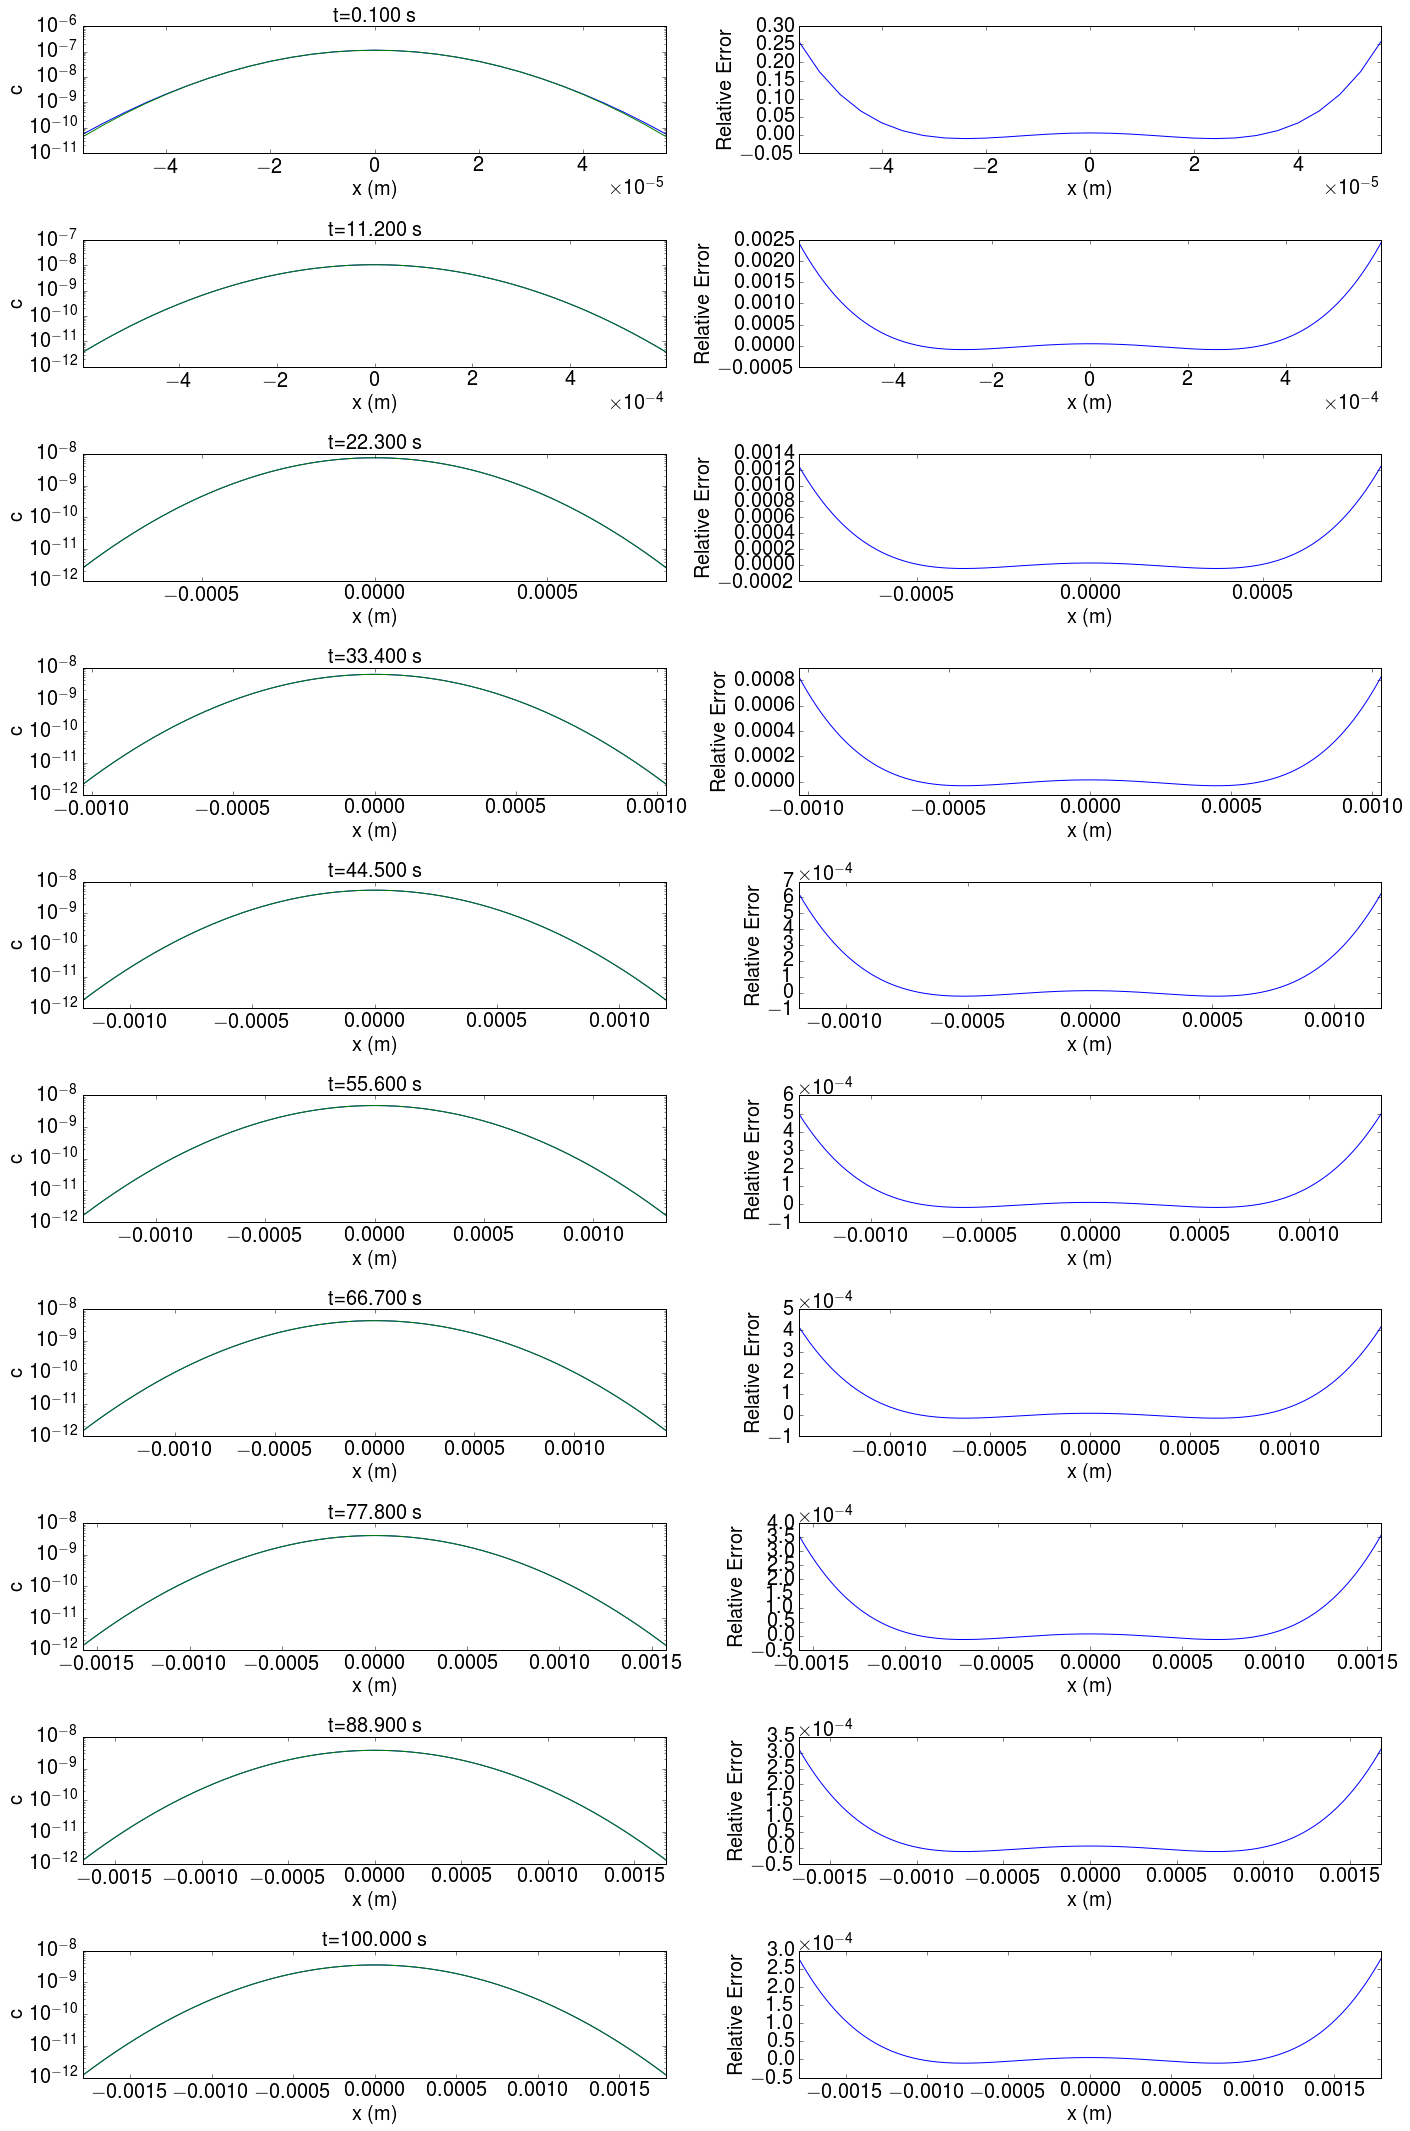

In [103]:
l=4e-6
N=1e-6*l
D=1000e-12
screen_style()
rows=10
cols=2
matplotlib.rcParams.update({"figure.figsize": (20,3*rows)})
plotIndex=1
for i in np.linspace(1,times.shape[0]-1,rows, dtype=int):
    t=times[i]
    xlimit=4*sqrt(2*D*t)/l
    xlimit=(int(ceil(grids.shape[1]/2-xlimit)),int(ceil(grids.shape[1]/2+xlimit)))
    x=(np.arange(0,grids.shape[1])-grids.shape[1]/2)*l
    x=x[xlimit[0]:xlimit[1]]
    c=grids[i,xlimit[0]:xlimit[1]]
    ctheory=(N/sqrt(4*pi*D*t))*exp(-((x**2)/(4*D*t)))
    subplot(rows,cols,plotIndex)
    plot(x, c)
    plot(x,ctheory)
    xlim([x[0],x[-1]]); xlabel(r"x (m)"); yscale("log"); ylabel("c"); title("t=%0.3f s"%t)
    plotIndex += 1
    subplot(rows,cols,plotIndex)
    err=(c-ctheory)/ctheory
    plot(x,err)
    xlim([x[0],x[-1]]); xlabel(r"x (m)"); ylabel("Relative Error");
    plotIndex += 1
plt.tight_layout()
pass

### Compare the numeric and analytic variance as a function of time.
The variance as a function of time is given by $\sigma^2(t) = 2Dt$.

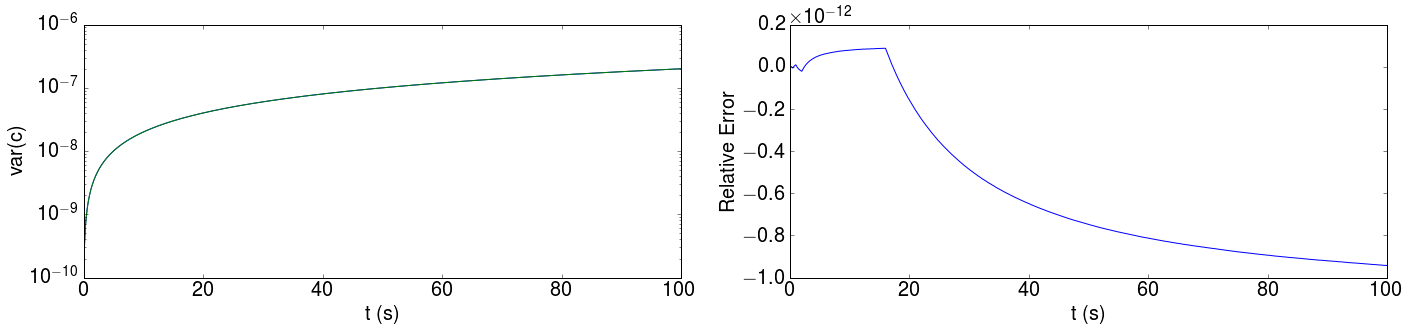

In [105]:
l=4e-6
D=1000e-12
screen_style()
matplotlib.rcParams.update({"figure.figsize": (20,5)})
subplot(1,2,1)
x=(np.arange(0,grids.shape[1])-grids.shape[1]/2)*l
t=times
varSim=np.zeros(times.shape)
for i in range(0,len(varSim)):
    c=grids[i,:]
    N=np.sum(c)
    varSim[i]=np.sum((x**2)*c/N)
varTheory=2*D*t
plot(t[1:],varSim[1:]);
plot(t[1:],varTheory[1:]);
xlabel("t (s)"); yscale("log"); ylabel("var(c)")
subplot(1,2,2)
err=(varSim-varTheory)/varTheory
plot(t,err)
xlabel("t (s)");  ylabel("Relative Error");
plt.tight_layout()
pass

# Regression tests for 2D diffusion.

### Execute a simulation of a 2D diffusion domain.

In [106]:
dirname="data/3"

# Create the microenv model input file.
import lm.input.SimulationInput_pb2 as inp
import lm.io.BoundaryConditions_pb2 as bc
from robertslab import ndarray
from robertslab.sfile import SFile

input=inp.SimulationInput()

# Build the microenv model.
gridShape=(1,200,200)
input.microenv_model.initial_time = 0.0;
input.microenv_model.synchronization_timestep = 0.01;
input.microenv_model.grid_shape.extend(gridShape)
input.microenv_model.grid_spacing = 4.0e-6
input.microenv_model.species_ids.append(0)
input.microenv_model.diffusion_coefficients.append(1000e-12)
input.microenv_model.boundaries.axis_specific_boundaries = True
input.microenv_model.boundaries.x_plus = bc.BoundaryConditions().REFLECTING
input.microenv_model.boundaries.x_minus = bc.BoundaryConditions().REFLECTING
input.microenv_model.boundaries.y_plus = bc.BoundaryConditions().LINEAR_GRADIENT
input.microenv_model.boundaries.y_minus = bc.BoundaryConditions().LINEAR_GRADIENT
input.microenv_model.boundaries.z_plus = bc.BoundaryConditions().LINEAR_GRADIENT
input.microenv_model.boundaries.z_minus = bc.BoundaryConditions().LINEAR_GRADIENT
grid = np.zeros(gridShape)
grid[grid.shape[0]//2,grid.shape[1]//2,grid.shape[2]//2] = 1.0e-6
ndarray.serializeInto(input.microenv_model.initial_concentrations.add(), grid)

# Write the input to the file.
filename="%s/input.sfile"%dirname
file=SFile.fromFilename(filename, "w")
file.writeRecord("input", "protobuf:lm.input.SimulationInput", stringData=input.SerializeToString())
file.close()
print "Finished."

Wrote 1523 byte of string data
Finished.


In [108]:
%%bash
dirname=data/3
filename=${dirname}/microenv_diffusion.lm
ifilename=${dirname}/input.sfile
ofilename=${dirname}/output.sfile
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} microenv_diffusion.sbml
lm_setp ${filename} writeInterval=1e-1 maxTime=1e1
rm -f ${sfilename}
echo "Execute the following command in `pwd`:"
echo "lmes -me -f ${filename},${ifilename} -gr 0 -c 3 -r 0 -ff sfile -fo ${ofilename}" -sl lm::cme::GillespieDSolver

lm_sbml_import v2016.05.10 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


2016-05-27 12:16:04) Processing 1 compartments.
2016-05-27 12:16:04) Added compartment (0) V: 1.000000e+00
2016-05-27 12:16:04) Processing 1 species.
2016-05-27 12:16:04) Added species (0) n with initial count: 1000
2016-05-27 12:16:04) Processing 1 reactions.
2016-05-27 12:16:04) Matched kinetic formula in reaction (0)  to FirstOrderPropensity: [1 * n] == [k1 * x1]
2016-05-27 12:16:04) There output file was successfully genereated.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/3/microenv_diffusion.lm:
maxTime=1e1
writeInterval=1e-1
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/microenv_diffusion:
lmes -me -f data/3/microenv_diffus

### Load the concentration time series.

In [109]:
# Set the filename.
dirname="data/3"
filename="%s/output.sfile"%dirname

from robertslab import ndarray
from robertslab.sfile import SFile
import lm.io.ConcentrationsTimeSeries_pb2 as cts

# Get the grid size and count the entries.
numberRecords=0
gridShape=None
file=SFile.fromFilename(filename, "r")
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.name == "/Simulations/0/ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        numberRecords += obj.times.shape[0]
        if gridShape is None:
            gridShape = tuple(obj.concentrations[0].shape)
    else:
        file.skipData(record.dataSize)
file.close();

# Load the records for this replicate.
index=0
times=np.zeros((numberRecords,), dtype=float)
grids=np.zeros((numberRecords,gridShape[1],gridShape[2]), dtype=float)
file=SFile.fromFilename(filename, "r")
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.name == "/Simulations/0/ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        recordTimes = ndarray.deserializeMessage(obj.times)
        for j in range(0,recordTimes.shape[0]):
            times[index] = recordTimes[j]
            grids[index,:,:] = ndarray.deserializeMessage(obj.concentrations[j])
            index += 1
    else:
        file.skipData(record.dataSize)
file.close();
print "Finished loading, grid shape was: ",gridShape,", number of time points was: ",len(times)
pass

Finished loading, grid shape was:  (1, 200, 200) , number of time points was:  101


### Plot the concentration vs time.

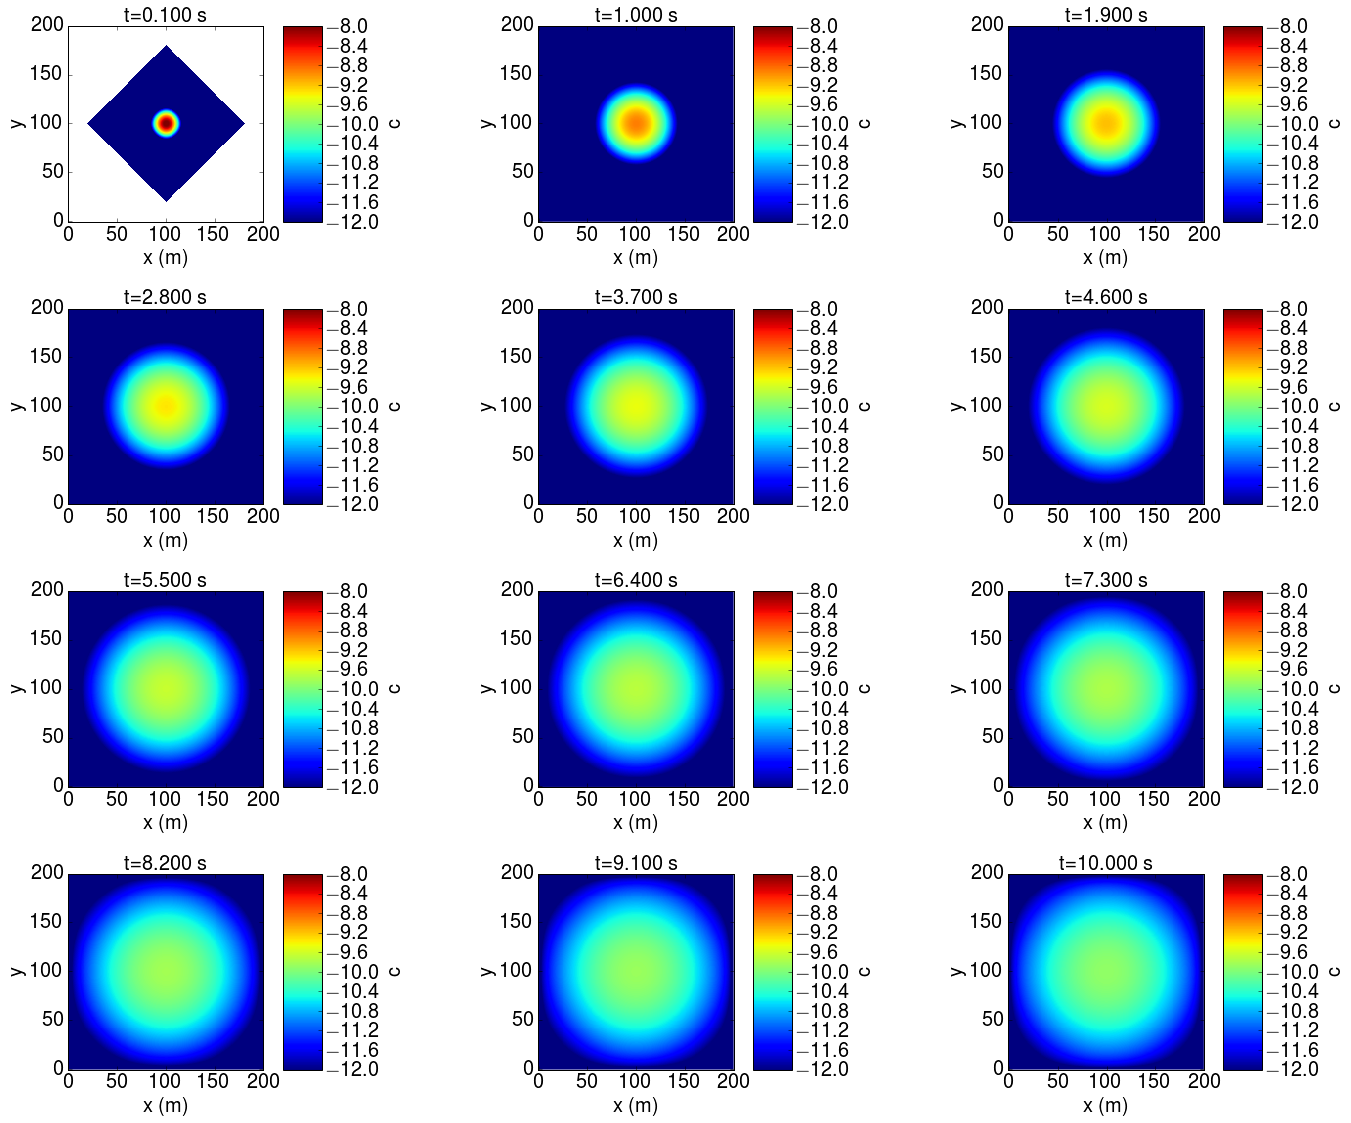

In [110]:
screen_style()
rows=4
cols=3
matplotlib.rcParams.update({"figure.figsize": (20,4*rows)})
plotIndex=1
for plotIndex,i in enumerate(np.linspace(1,times.shape[0]-1,rows*cols, dtype=int)):
    subplot(rows,cols,plotIndex+1)
    imshow(log10(grids[i,:,:]), interpolation='none', aspect=1, origin='lower', vmin=-12, vmax=-8)
    cb=colorbar(label="c"); cb.ax.set_aspect(5)
    xlabel(r"x (m)"); ylabel("y"); title("t=%0.3f s"%times[i])
plt.tight_layout()
pass

### Compare the numeric and analytic concentration at different times.
The concentration as a fucntion of $x$, $y$, and $t$ is given by $c(x,y,t) = \frac{N}{4{\pi}Dt} exp(-\frac{x^2+y^2}{4Dt})$, where $N=\int_{-\infty}^{\infty}\int_{-\infty}^{\infty}c(x,y,t)\,dx\,dy$. See http://www.rpgroup.caltech.edu/courses/aph162/2006/Protocols/diffusion.pdf

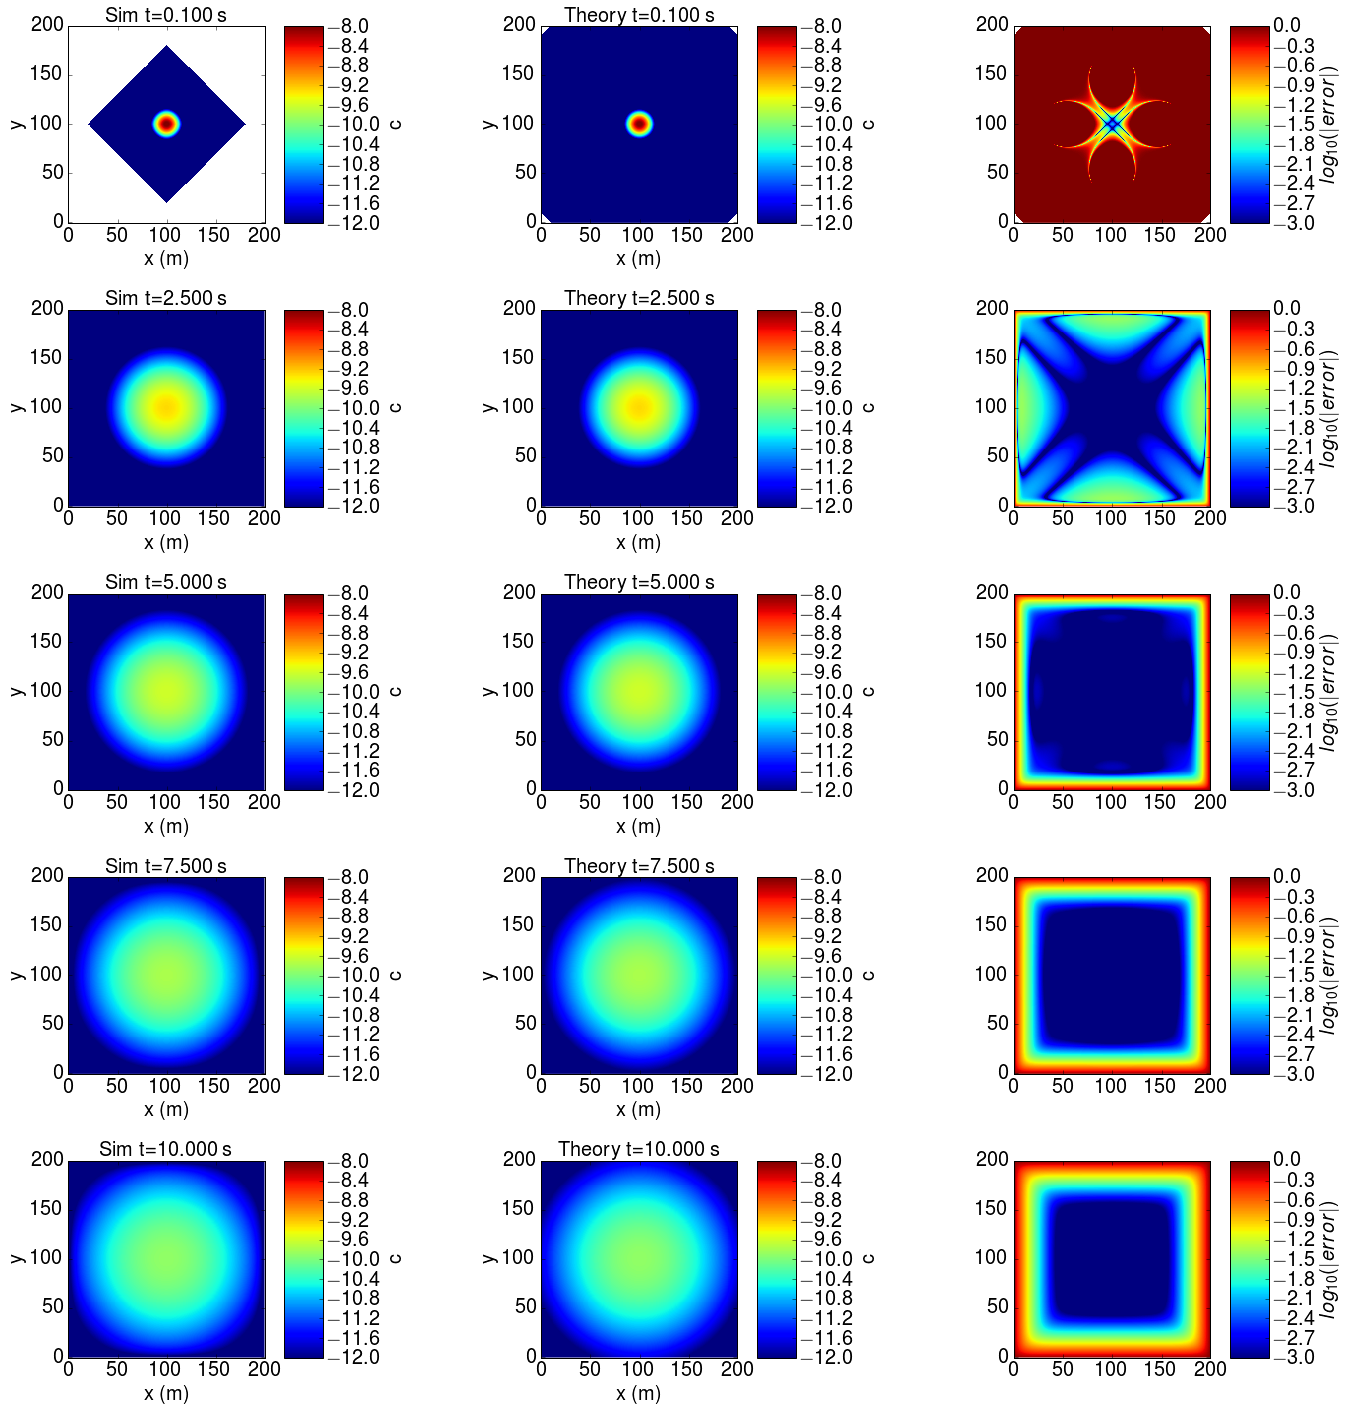

In [111]:
l=4e-6
N=1e-6*l*l
D=1000e-12
screen_style()
rows=5
cols=3
matplotlib.rcParams.update({"figure.figsize": (20,4*rows)})
plotIndex=1
for i in np.linspace(1,times.shape[0]-1,rows, dtype=int):
    t=times[i]
    x=(np.arange(0,grids.shape[1])-grids.shape[1]/2)*l
    y=(np.arange(0,grids.shape[2])-grids.shape[2]/2)*l
    c=grids[i,:,:]
    cTheory=np.zeros(c.shape)
    for j in range(0,cTheory.shape[1]):
        cTheory[:,j]=(N/(4*pi*D*t))*exp(-((x**2+y[j]**2)/(4*D*t)))
    subplot(rows,cols,plotIndex)
    imshow(log10(c), interpolation='none', aspect=1, origin='lower', vmin=-12, vmax=-8)
    cb=colorbar(label="c"); cb.ax.set_aspect(5)
    xlabel(r"x (m)"); ylabel("y"); title("Sim t=%0.3f s"%times[i])
    plotIndex += 1
    subplot(rows,cols,plotIndex)
    imshow(log10(cTheory), interpolation='none', aspect=1, origin='lower', vmin=-12, vmax=-8)
    cb=colorbar(label="c"); cb.ax.set_aspect(5)
    xlabel(r"x (m)"); ylabel("y"); title("Theory t=%0.3f s"%times[i])
    plotIndex += 1
    subplot(rows,cols,plotIndex)
    err=np.abs(c-cTheory)/cTheory
    imshow(log10(err), interpolation='none', aspect=1, origin='lower', vmin=-3, vmax=0)
    cb=colorbar(label="$log_{10}(|error|)$"); cb.ax.set_aspect(5)
    plotIndex += 1
plt.tight_layout()
pass

### Compare the numeric and analytic variance as a function of time.
The variance as a function of time is given by $\sigma^2(t) = 4Dt$.

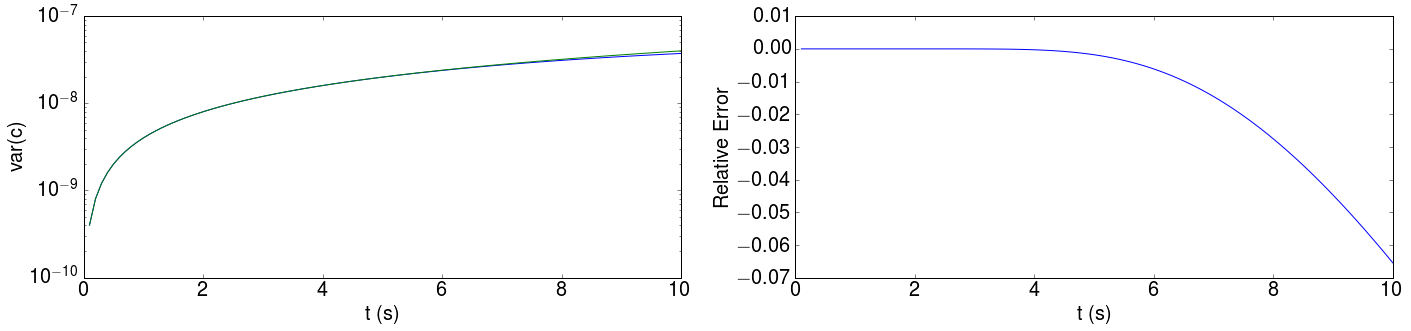

In [112]:
l=4e-6
N=1e-6*l*l
D=1000e-12
screen_style()
matplotlib.rcParams.update({"figure.figsize": (20,5)})
subplot(1,2,1)
x=(np.arange(0,grids.shape[1])-grids.shape[1]/2)*l
y=(np.arange(0,grids.shape[2])-grids.shape[2]/2)*l
t=times
varSim=np.zeros(times.shape)
for i in range(0,len(varSim)):
    c=grids[i,:,:]
    N=np.sum(c)
    varSim[i]=np.sum((x**2+y**2)*c/N)
varTheory=4*D*t
plot(t[1:],varSim[1:]);
plot(t[1:],varTheory[1:]);
xlabel("t (s)"); yscale("log"); ylabel("var(c)")
subplot(1,2,2)
err=(varSim-varTheory)/varTheory
plot(t,err)
xlabel("t (s)");  ylabel("Relative Error");
plt.tight_layout()
pass

# Regression tests for 3D diffusion.

### Execute a simulation of a 3D diffusion domain.

In [113]:
dirname="data/4"
filename="%s/input.sfile"%dirname

# Create the microenv model input file.
import lm.input.SimulationInput_pb2 as inp
import lm.io.BoundaryConditions_pb2 as bc
from robertslab import ndarray
from robertslab.sfile import SFile

input=inp.SimulationInput()

# Build the microenv model.
gridShape=(200,200,200)
input.microenv_model.initial_time = 0.0;
input.microenv_model.synchronization_timestep = 0.01;
input.microenv_model.grid_shape.extend(gridShape)
input.microenv_model.grid_spacing = 4.0e-6
input.microenv_model.species_ids.append(0)
input.microenv_model.diffusion_coefficients.append(1000e-12)
input.microenv_model.boundaries.axis_specific_boundaries = True
input.microenv_model.boundaries.x_plus = bc.BoundaryConditions().LINEAR_GRADIENT
input.microenv_model.boundaries.x_minus = bc.BoundaryConditions().LINEAR_GRADIENT
input.microenv_model.boundaries.y_plus = bc.BoundaryConditions().LINEAR_GRADIENT
input.microenv_model.boundaries.y_minus = bc.BoundaryConditions().LINEAR_GRADIENT
input.microenv_model.boundaries.z_plus = bc.BoundaryConditions().LINEAR_GRADIENT
input.microenv_model.boundaries.z_minus = bc.BoundaryConditions().LINEAR_GRADIENT
grid = np.zeros(gridShape)
grid[grid.shape[0]//2,grid.shape[1]//2,grid.shape[2]//2] = 1.0e-6
ndarray.serializeInto(input.microenv_model.initial_concentrations.add(), grid)

# Write the input to the file.
file=SFile.fromFilename(filename, "w")
file.writeRecord("input", "protobuf:lm.input.SimulationInput", stringData=input.SerializeToString())
file.close()
print "Finished."

Wrote 279403 byte of string data
Finished.


In [115]:
%%bash
dirname=data/4
filename=${dirname}/microenv_diffusion.lm
ifilename=${dirname}/input.sfile
ofilename=${dirname}/output.sfile
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} microenv_diffusion.sbml
lm_setp ${filename} writeInterval=1e-1 maxTime=1e0
rm -f ${sfilename}
echo "Execute the following command in `pwd`:"
echo "lmes -me -f ${filename},${ifilename} -gr 0 -c 3 -r 0 -ff sfile -fo ${ofilename}" -sl lm::cme::GillespieDSolver

lm_sbml_import v2016.05.10 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


2016-05-27 12:18:56) Processing 1 compartments.
2016-05-27 12:18:56) Added compartment (0) V: 1.000000e+00
2016-05-27 12:18:56) Processing 1 species.
2016-05-27 12:18:56) Added species (0) n with initial count: 1000
2016-05-27 12:18:56) Processing 1 reactions.
2016-05-27 12:18:56) Matched kinetic formula in reaction (0)  to FirstOrderPropensity: [1 * n] == [k1 * x1]
2016-05-27 12:18:56) There output file was successfully genereated.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/4/microenv_diffusion.lm:
maxTime=1e0
writeInterval=1e-1
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/microenv_diffusion:
lmes -me -f data/4/microenv_diffus

### Load the concentration time series.

In [116]:
# Set the filename.
dirname="data/4"
filename="%s/output.sfile"%dirname

from robertslab import ndarray
from robertslab.sfile import SFile
import lm.io.ConcentrationsTimeSeries_pb2 as cts

# Get the grid size and count the entries.
numberRecords=0
gridShape=None
file=SFile.fromFilename(filename, "r")
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.name == "/Simulations/0/ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        numberRecords += obj.times.shape[0]
        if gridShape is None:
            gridShape = tuple(obj.concentrations[0].shape)
    else:
        file.skipData(record.dataSize)
file.close();

# Load the records for this replicate.
index=0
times=np.zeros((numberRecords,), dtype=float)
grids=np.zeros((numberRecords,gridShape[0],gridShape[1],gridShape[2]), dtype=float)
file=SFile.fromFilename(filename, "r")
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.name == "/Simulations/0/ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        recordTimes = ndarray.deserializeMessage(obj.times)
        for j in range(0,recordTimes.shape[0]):
            times[index] = recordTimes[j]
            grids[index,:,:,:] = ndarray.deserializeMessage(obj.concentrations[j])
            index += 1
    else:
        file.skipData(record.dataSize)
file.close();
print "Finished loading, grid shape was: ",gridShape,", number of time points was: ",len(times)
pass

Finished loading, grid shape was:  (200, 200, 200) , number of time points was:  12


### Plot the concentration vs time for a few z planes.

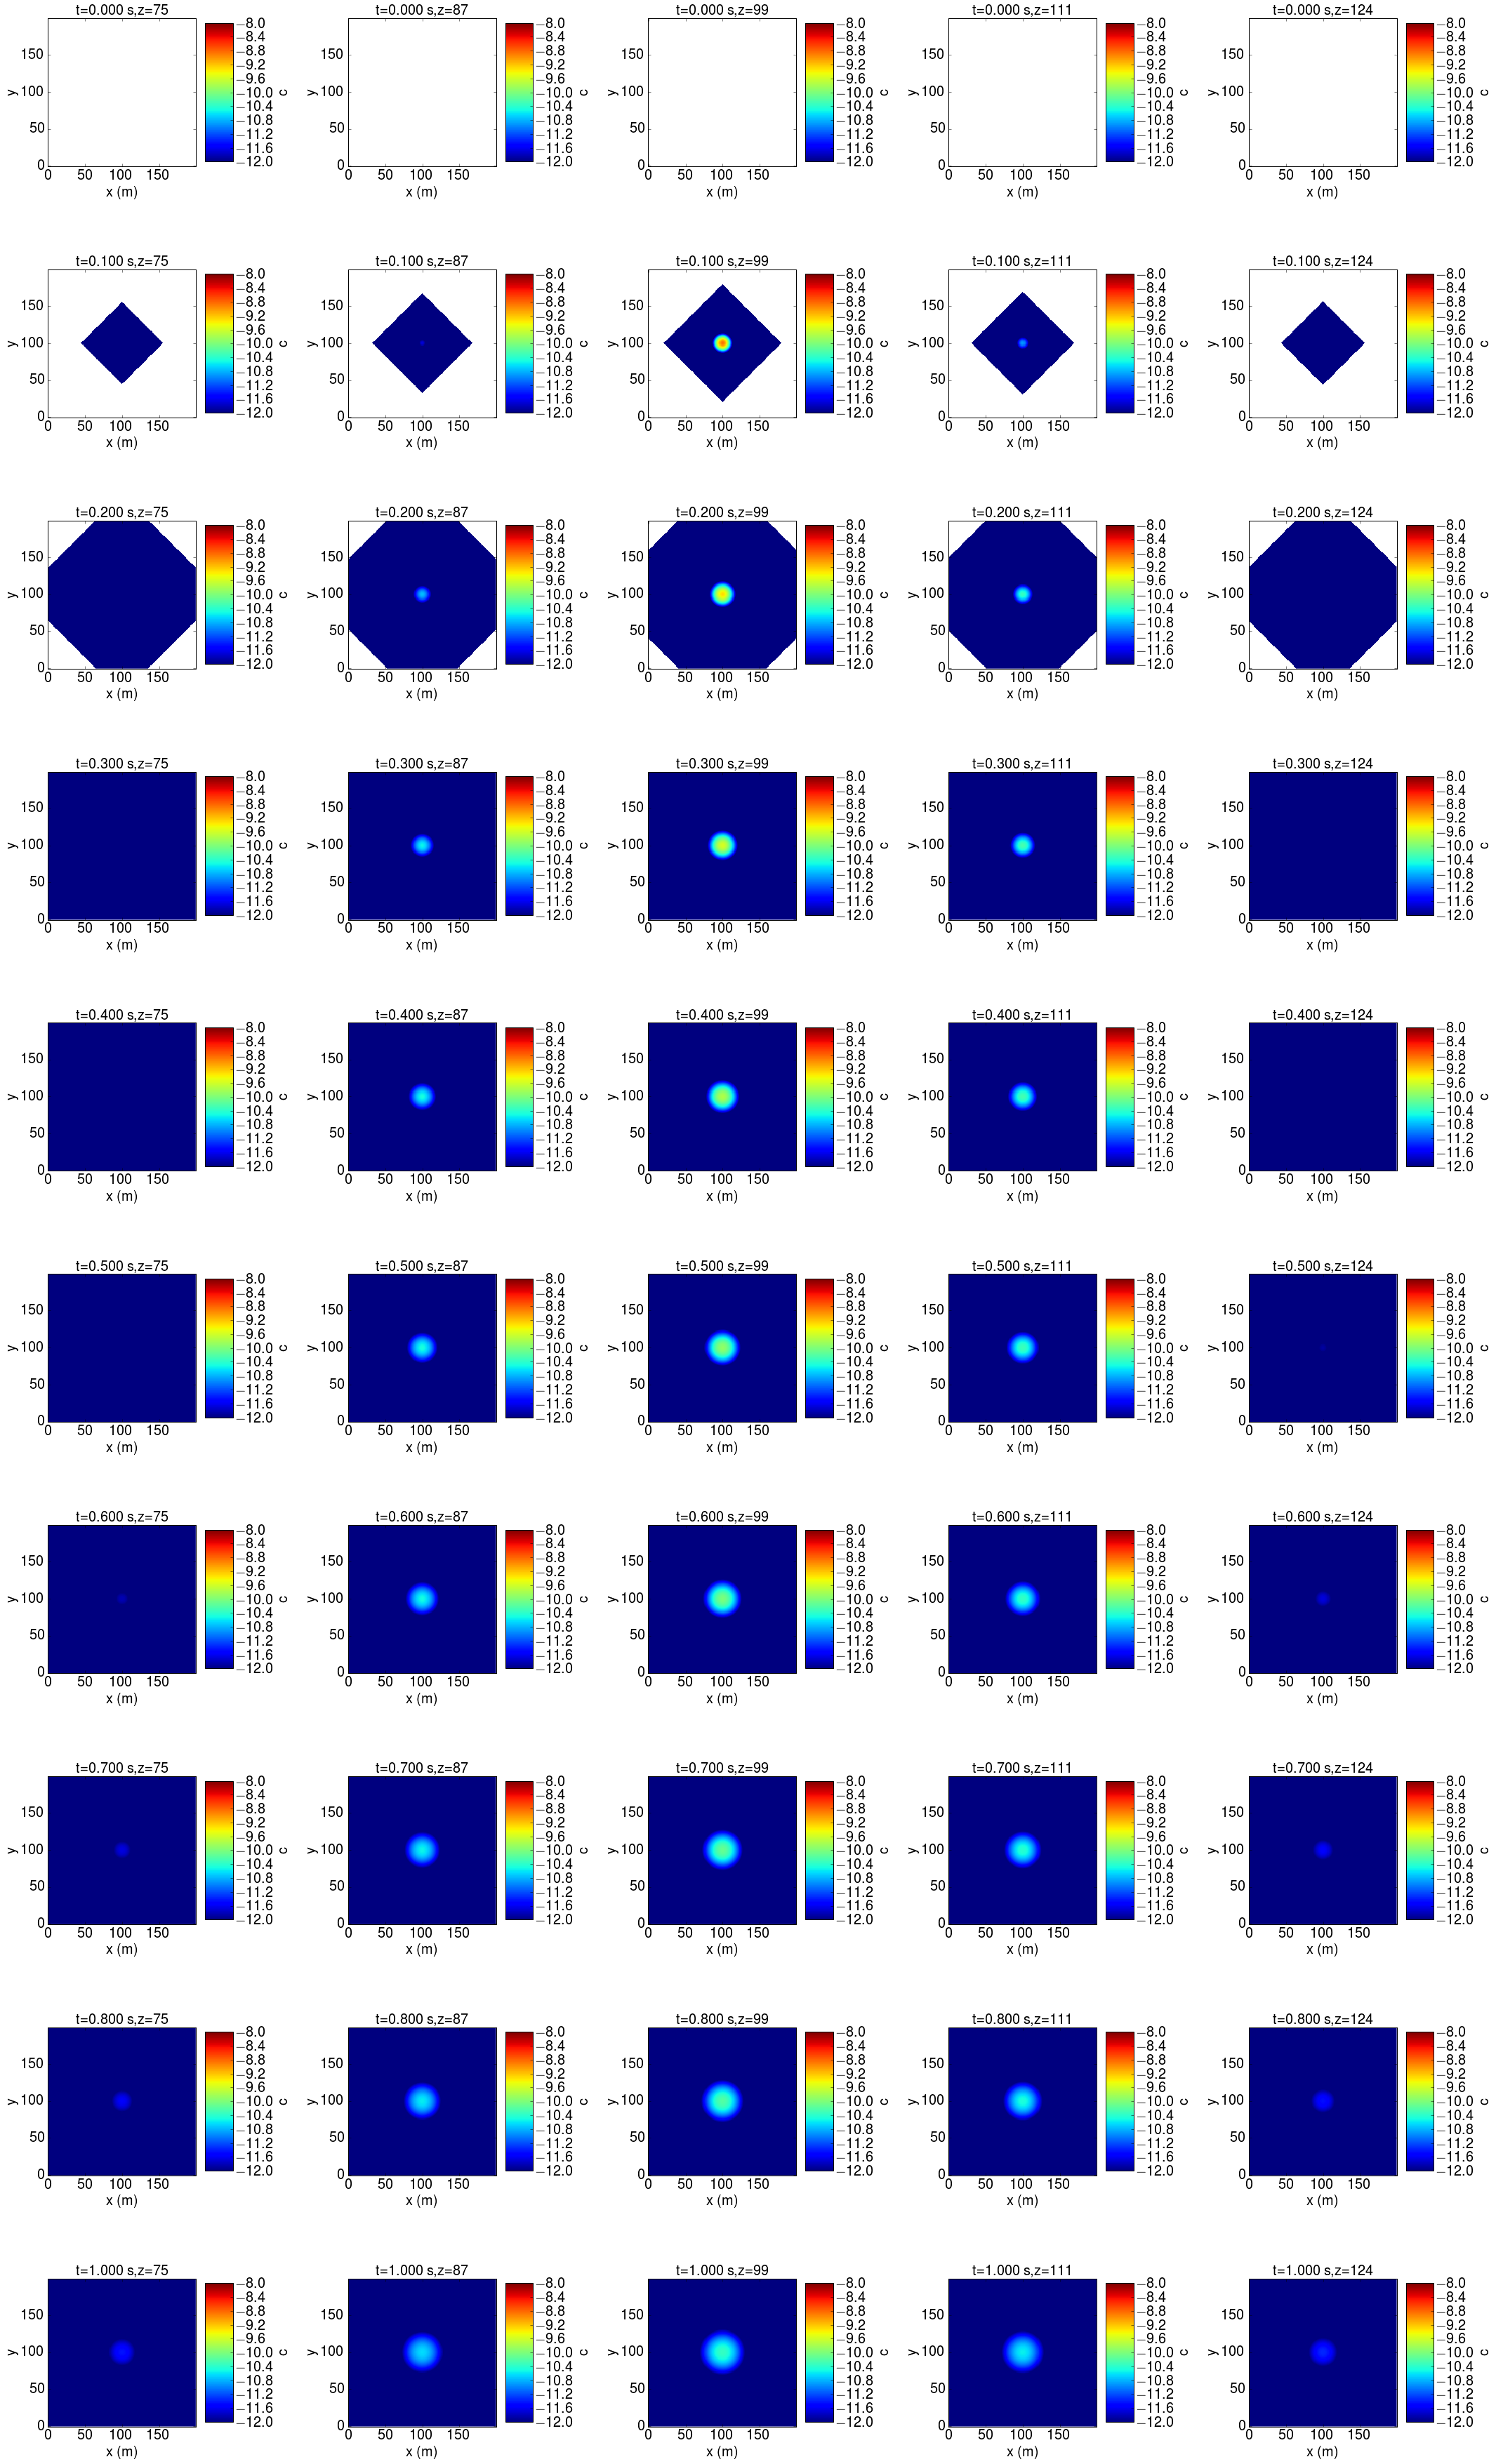

In [117]:
screen_style()
rows=10
cols=5
zoffset=75
matplotlib.rcParams.update({"figure.figsize": (30,5*rows)})
plotIndex=1
for plotRow,i in enumerate(np.linspace(1,times.shape[0]-1,rows, dtype=int)):
    for plotCol,l in enumerate(np.linspace(zoffset,gridShape[2]-1-zoffset,cols, dtype=int)):
        subplot(rows,cols,plotRow*cols+plotCol+1)
        imshow(log10(grids[i,:,:,l]), interpolation='none', aspect=1, origin='lower', vmin=-12, vmax=-8)
        cb=colorbar(label="c"); cb.ax.set_aspect(5)
        xlabel(r"x (m)"); ylabel("y"); title("t=%0.3f s,z=%d"%(times[i],l))
plt.tight_layout()
pass

### Compare the numeric and analytic concentration at different times for a given x/y plane.
The concentration as a fucntion of $x$, $y$, $z$, and $t$ is given by $c(x,y,z,t) = \frac{N}{(4{\pi}Dt)^{3/2}} exp(-\frac{x^2+y^2+z^2}{4Dt})$, where $N=\int_{-\infty}^{\infty}\int_{-\infty}^{\infty}\int_{-\infty}^{\infty}c(x,y,z,t)\,dx\,dy\,dz$.

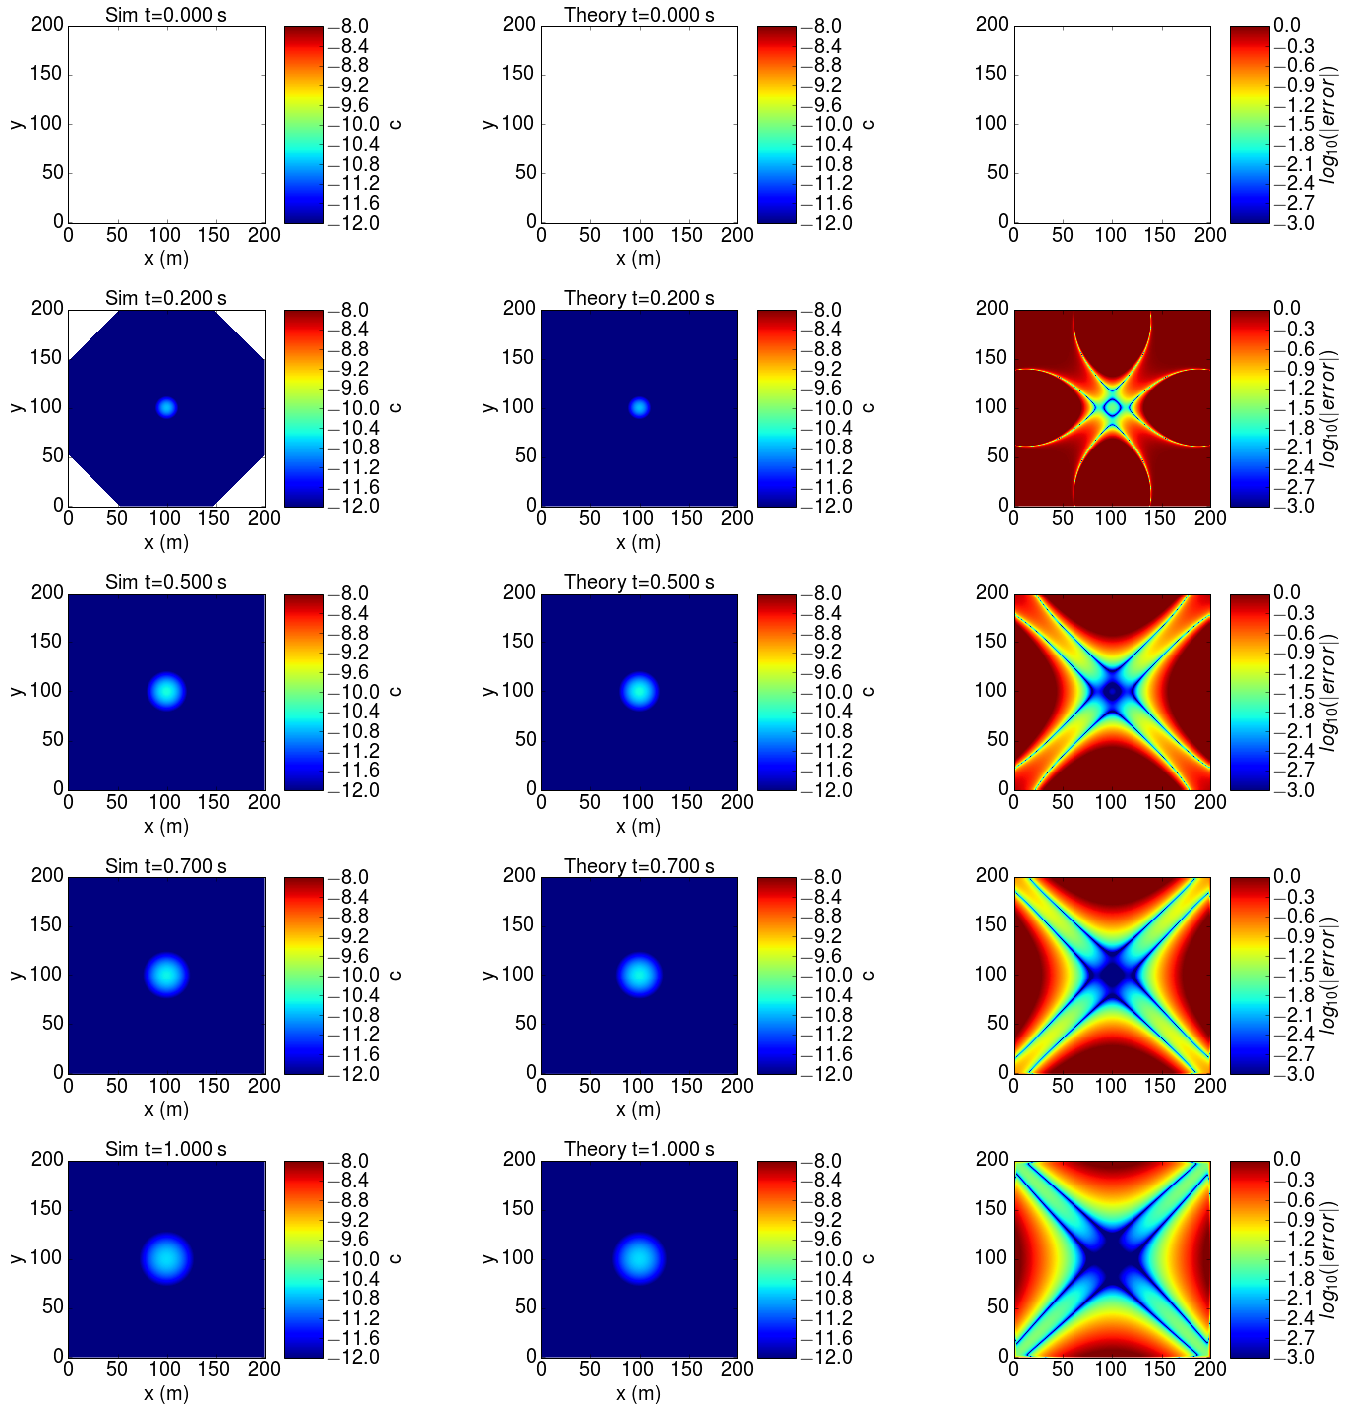

In [119]:
l=4e-6
N=1e-6*l*l*l
D=1000e-12
zindex=87
screen_style()
rows=5
cols=3
matplotlib.rcParams.update({"figure.figsize": (20,4*rows)})
plotIndex=1
for i in np.linspace(1,times.shape[0]-1,rows, dtype=int):
    t=times[i]
    x=(np.arange(0,grids.shape[1])-grids.shape[1]/2)*l
    y=(np.arange(0,grids.shape[2])-grids.shape[2]/2)*l
    z=(zindex-grids.shape[3]/2)*l
    c=grids[i,:,:,zindex]
    cTheory=np.zeros(c.shape)
    for j in range(0,cTheory.shape[1]):
        cTheory[:,j]=(N/(4*pi*D*t)**(3.0/2.0))*exp(-((x**2+y[j]**2+z**2)/(4*D*t)))
    subplot(rows,cols,plotIndex)
    imshow(log10(c), interpolation='none', aspect=1, origin='lower', vmin=-12, vmax=-8)
    cb=colorbar(label="c"); cb.ax.set_aspect(5)
    xlabel(r"x (m)"); ylabel("y"); title("Sim t=%0.3f s"%times[i])
    plotIndex += 1
    subplot(rows,cols,plotIndex)
    imshow(log10(cTheory), interpolation='none', aspect=1, origin='lower', vmin=-12, vmax=-8)
    cb=colorbar(label="c"); cb.ax.set_aspect(5)
    xlabel(r"x (m)"); ylabel("y"); title("Theory t=%0.3f s"%times[i])
    plotIndex += 1
    subplot(rows,cols,plotIndex)
    err=np.abs(c-cTheory)/cTheory
    imshow(log10(err), interpolation='none', aspect=1, origin='lower', vmin=-3, vmax=0)
    cb=colorbar(label="$log_{10}(|error|)$"); cb.ax.set_aspect(5)
    plotIndex += 1
plt.tight_layout()
pass

### Compare the numeric and analytic variance as a function of time.
The variance as a function of time is given by $\sigma^2(t) = 6Dt$.

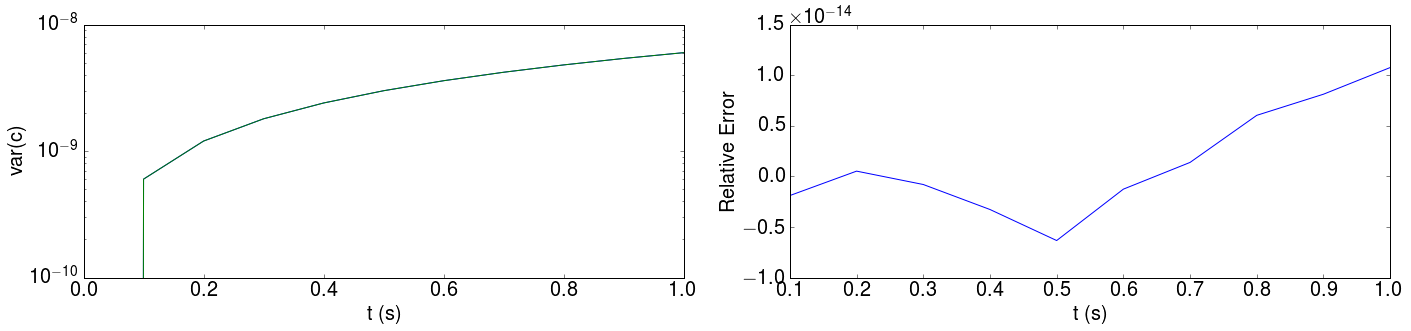

In [120]:
l=4e-6
N=1e-6*l*l*l
D=1000e-12
screen_style()
matplotlib.rcParams.update({"figure.figsize": (20,5)})
subplot(1,2,1)
x=(np.arange(0,grids.shape[1])-grids.shape[1]/2)*l
y=(np.arange(0,grids.shape[2])-grids.shape[2]/2)*l
z=(np.arange(0,grids.shape[3])-grids.shape[3]/2)*l
t=times
varSim=np.zeros(times.shape)
for i in range(0,len(varSim)):
    c=grids[i,:,:,:]
    N=np.sum(c)
    varSim[i]=np.sum((x**2+y**2+z**2)*c/N)
varTheory=6*D*t
plot(t[1:],varSim[1:]);
plot(t[1:],varTheory[1:]);
xlabel("t (s)"); yscale("log"); ylabel("var(c)")
subplot(1,2,2)
err=(varSim-varTheory)/varTheory
plot(t,err)
xlabel("t (s)");  ylabel("Relative Error");
plt.tight_layout()
pass